# Case 5: Klastering Daya Serap Tenaga Kerja

Menganalisis karakteristik penyerapan tenaga kerja. Seberapa banyak lapangan pekerjaan yang berhasil diciptakan oleh kelompok UMKM tertentu?

**Fokus Fitur yang Digunakan:**
- Total Pekerja Numeric
- Rerata Usia Pekerja Numeric
- Omset Numeric

---
Notebook ini dirancang secara modular dan memanggil fungsi algoritma inti dari `../src/csa_core.py`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
import sys
import os
sys.path.append(os.path.abspath('../src'))

from csa_core import *
np.random.seed(42)

### 1. Load Data Bersih & Persiapan Fitur

In [2]:
df = pd.read_excel('../data/Data_UMKM_Clean.xlsx')

fitur_yang_dipakai = ['Total Pekerja Numeric', 'Rerata Usia Pekerja Numeric', 'Omset Numeric']

X_raw = df[fitur_yang_dipakai].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Mengeksekusi Case dengan {len(fitur_yang_dipakai)} Dimensi!")
display(df[['Nama Usaha'] + fitur_yang_dipakai].head(5))

Mengeksekusi Case dengan 3 Dimensi!


,Nama Usaha,Total Pekerja Numeric,Rerata Usia Pekerja Numeric,Omset Numeric
0,NASYWA SNACK,0,0,5.0
1,WARUNG ABINAYA,0,3,5.0
2,TUNGKU MA ENDANG,2,3,5.0
3,WARUNG BU WIWIK,4,1,5.0
4,WARUNG PNUNG,0,0,5.0


### 2. Menghitung Jumlah Klaster Optimal (Elbow Method)

Mengkalkulasi K-Optimal...


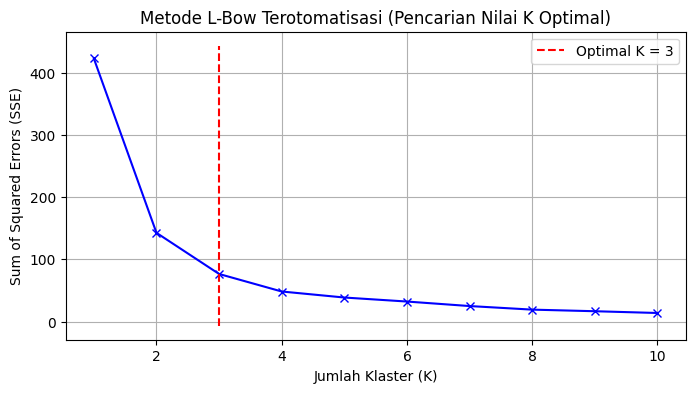

Rekomendasi K-Optimal adalah: 3


In [3]:
print("Mengkalkulasi K-Optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=10)
print(f"Rekomendasi K-Optimal adalah: {optimal_k}")

### 3. Eksekusi KMeans

In [4]:
print(f"Mengeksekusi K-Means Konvensional untuk K={optimal_k}...")
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
final_labels = kmeans.fit_predict(X_scaled)
final_centroids_scaled = kmeans.cluster_centers_


df['Cluster'] = final_labels
df['Cluster'] = df['Cluster'].apply(lambda x: f"C{int(x)+1}")

display(df[['Nama Usaha'] + fitur_yang_dipakai + ['Cluster']].head(10))

Mengeksekusi K-Means Konvensional untuk K=3...


,Nama Usaha,Total Pekerja Numeric,Rerata Usia Pekerja Numeric,Omset Numeric,Cluster
0,NASYWA SNACK,0,0,5.0,C1
1,WARUNG ABINAYA,0,3,5.0,C2
2,TUNGKU MA ENDANG,2,3,5.0,C2
3,WARUNG BU WIWIK,4,1,5.0,C1
4,WARUNG PNUNG,0,0,5.0,C1
5,KRISNA TRANSPORT,1,2,5.0,C2
6,LAUNDRY WINA,0,0,5.0,C1
7,JP CATERING,2,3,17.5,C2
8,SANDANG TRIAN,2,2,5.0,C2
9,JUALAN ES KELAPA MUDA,1,2,17.5,C2


### 4. Evaluasi & Visualisasi

Menggambar Visualisasi Sebaran Klaster...


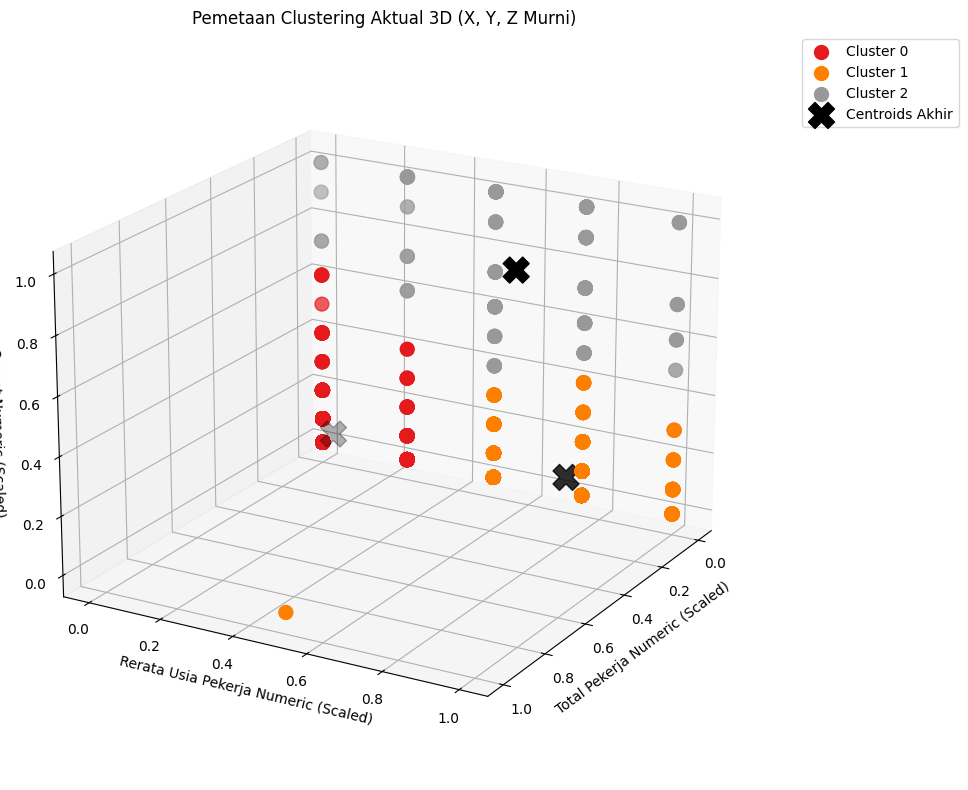


=== EVALUASI METRIK ===
      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.7100
   [Interpretasi]: SANGAT BAGUS. Data terstruktur dengan kokoh.

2. Davies-Bouldin Index (DBI): 0.5486
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 5926.3655
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 76.4959
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 0.1706
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.


In [5]:
print("Menggambar Visualisasi Sebaran Klaster...")
plot_hasil_cluster(X_scaled, final_centroids_scaled, final_labels, fitur_yang_dipakai)

print("\n=== EVALUASI METRIK ===")
evaluasi_kualitas_klasterisasi(X_scaled, final_labels, final_centroids_scaled)

In [6]:
import plotly.express as px

# =========================================================
# 1. Visualisasi 3D Interaktif (Total Pekerja vs Usia vs Omset)
# =========================================================
fig_3d_c5 = px.scatter_3d(
    df, 
    x=fitur_yang_dipakai[0], # Total Pekerja Numeric
    y=fitur_yang_dipakai[1], # Rerata Usia Pekerja Numeric
    z=fitur_yang_dipakai[2], # Omset Numeric
    color='Cluster',
    hover_name='Nama Usaha',
    title="Peta 3D: Daya Serap Tenaga Kerja UMKM",
    opacity=0.8,
    size_max=12,
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig_3d_c5.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d_c5.show()


# =========================================================
# 2. Bar Chart (Pembandingan Profil Rata-rata Ketenagakerjaan)
# =========================================================
# Mengambil rata-rata metrik dari setiap klaster
df_avg_c5 = df.groupby('Cluster')[fitur_yang_dipakai].mean().reset_index()

# Melakukan transformasi data (melt)
df_melted_c5 = df_avg_c5.melt(id_vars='Cluster', value_vars=fitur_yang_dipakai, 
                        var_name='Variabel', value_name='Rata-rata Angka')

# Menggambar diagram batang
fig_bar_c5 = px.bar(
    df_melted_c5, 
    x='Cluster', 
    y='Rata-rata Angka', 
    color='Variabel', 
    barmode='group',
    title="Profil Rata-rata Pekerja dan Omset per Klaster"
)
fig_bar_c5.show()
